# Experiment 7: **Adjusting Difficulty**

## Objective
In this experiment, we explore the claim that the difficulty of the games can be easily adjusted by modifying:
1. The number of players  
2. The thresholds of the players  

---

## Methodology

- **Evaluation Metrics:**  
  For each of these experiments, we compute:  
  - % 5/6-way agreement  
  - % 6-way agreement  
  - % Any agreement  

- **(1) Modifying the Number of Players:**  
  We run the base game with different numbers of players:  
  - 3 players  
  - 4 players  
  - 5 players  
  - 6 players (default)  

  The results of this experiment can be found in **Table 9**.  

- **(2) Modifying the Thresholds:**  
  We run the base game with variations in the thresholds:  
  - [-20, -10, -5, -3, 0, +3, +5, +10]  

  The results of this experiment can be found in **Figure 3**.  

---

## Results
The findings from these experiments illustrate how adjusting the number of players and their thresholds impacts the difficulty of the game. These results are presented in **Table 9** and **Figure 3** of our paper.


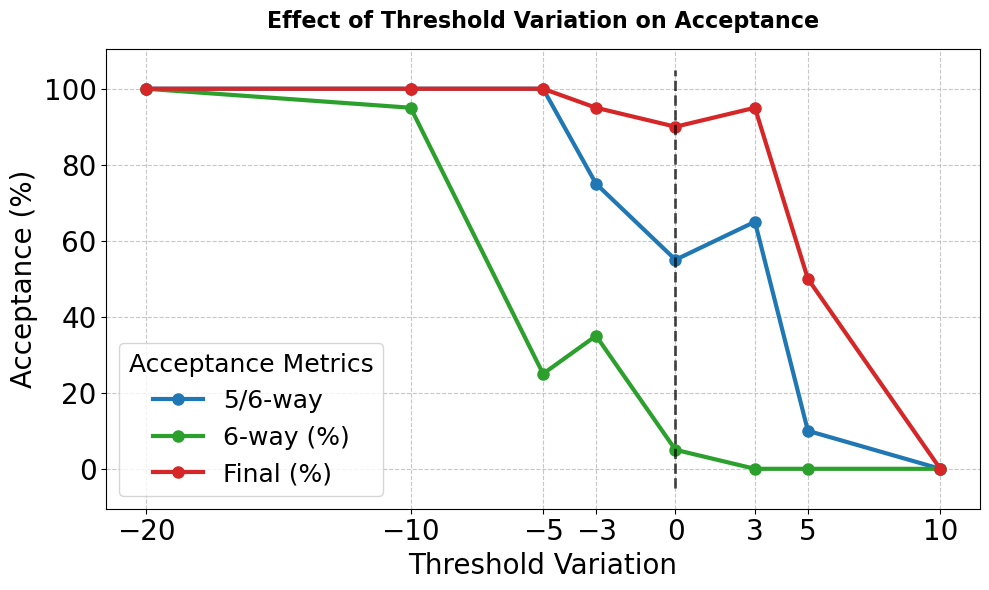

,5/6-way,6-way (%),Final (%),Threshold
minus_20,100.0,100.0,100.0,-20
minus_10,100.0,95.0,100.0,-10
minus_5,100.0,25.0,100.0,-5
minus_3,75.0,35.0,95.0,-3
base,55.0,5.0,90.0,0
plus_3,65.0,0.0,95.0,3
plus_5,10.0,0.0,50.0,5
plus_10,0.0,0.0,0.0,10


In [5]:
# (1) Changing the thresholds

import os
import eval_utils as evaluation
import json
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt


raw_path = '../our_games_descriptions/base_varying_thresholds'
variations = [
    "minus_20",
    "minus_10",
    "minus_5",
    "minus_3",
    "base",
    "plus_3",
    "plus_5",
    "plus_10",
]

model="gpt4o-mini"

results = {}
ISSUES_NUM = 5
AGENTS_NUM = 6

for variation in variations:
    
    # Set the directory
    if variation == 'base':
        directory = os.path.join('../our_games_descriptions/base/output/original_code', model)
    else:
        directory = os.path.join(raw_path, variation, 'output', model)

    # Load the setup
    agents, role_to_agents, incentive_to_agents = evaluation.load_setup(directory, AGENTS_NUM, num_issues=ISSUES_NUM)
    answers_files = [ os.path.join(directory,filename) for filename in os.listdir(directory) if filename.startswith("history")]

    num_rounds = 0
    for file_ in answers_files:
        answers = json.load(open(file_))
        _num_rounds = len(answers['rounds'])
        num_rounds = max(num_rounds, _num_rounds)

    # Track statistics
    feasible_in_last_step = 0
    accepted_by_all_in_last_step = 0
    contained_feasible_deal = 0
    successfull_games = 0
    total_rounds = 0

    # Loop through all answer files (each represents a game)
    for file_ in answers_files:
        answers = json.load(open(file_))
        
        if len(answers['rounds']) != num_rounds:
            print(f"WARNING: Game {file_} has a different number of rounds")
            continue
        total_rounds += len(answers['rounds'])
        successfull_games += 1

        # Extract deals for this game
        feasible_found = False

        # Extract the name of the first player (p1) to validate feasibility throughout the game
        p1_name = answers['rounds'][0]['agent']

        total_deals = 0
        
        for i, round_ in enumerate(answers['rounds']):
            name, answer = round_['agent'], round_['public_answer']
            deal_unformatted, issues_suggested = evaluation.extract_deal(answer, ISSUES_NUM)

            try:
                deal = evaluation.format_deal(deal_unformatted, ISSUES_NUM)
            except:
                print(f"Error in game {file_} round {i}")
                continue

            if issues_suggested >= ISSUES_NUM:
                total_deals += 1

            # Check if the deal was feasible at any point (Deal must have been proposed by p1)
            if evaluation.is_feasible(agents, deal) and name == p1_name:
                feasible_found = True
        

        # CHECK GAME COMPLETION METRICS

        last_deal = evaluation.format_deal(evaluation.extract_deal(answers['rounds'][-1]['public_answer'], ISSUES_NUM)[0], ISSUES_NUM)
        
        # 1. Check if the last deal is feasible
        if evaluation.is_feasible(agents, last_deal):
            feasible_in_last_step += 1

        # 2. Check if the last deal is acceptable by all agents
        all_accept = all(evaluation.calculator(agents[agent]["scores"], last_deal, ISSUES_NUM, verbose=False) >= agents[agent]["scores"]["min"] for agent in agents)
        if all_accept:
            accepted_by_all_in_last_step += 1

        # 3. Check if any deal during the game was in the feasibility set
        if feasible_found:
            contained_feasible_deal += 1

    # Compute percentages
    num_games = successfull_games
    perc_feasible_last = round((feasible_in_last_step / num_games) * 100, 2)
    perc_accepted_all_last = round((accepted_by_all_in_last_step / num_games) * 100, 2)
    perc_feasible_any = round((contained_feasible_deal / num_games) * 100, 2)

    results[variation] = {
        "5/6-way": perc_feasible_last,
        "6-way (%)": perc_accepted_all_last,
        "Final (%)": perc_feasible_any,
    }

df = pd.DataFrame(results).T

mapping = {
    "minus_20": -20, "minus_10": -10, "minus_5": -5, "minus_3": -3,
    "base": 0, "plus_3": 3, "plus_5": 5, "plus_10": 10
}
df["Threshold"] = df.index.map(mapping)

# --- PLOTTING ---

import matplotlib.pyplot as plt

# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the lines on the specified axes
# (Increasing linewidth, marker size, etc. to make it more visually appealing)
df.plot(
    x="Threshold",
    y=["5/6-way", "6-way (%)", "Final (%)"],
    kind="line",
    ax=ax,
    marker="o",
    markersize=8,
    linewidth=3,
    fontsize=20,  # font size for x/y tick labels
    color=["#1f77b4", "#2ca02c", "#d62728"],  # You can customize colors
)

# Suppose you have an axes object called ax:
ax.set_xlabel("Threshold Variation", fontsize=20)
ax.set_ylabel("Acceptance (%)", fontsize=20)


# Set title
ax.set_title(
    "Effect of Threshold Variation on Acceptance", 
    fontsize=16, 
    fontweight="bold", 
    pad=15
)

# Draw a vertical line at the 'base' threshold (0)
ymin, ymax = ax.get_ylim()  # for drawing the line over full y-range
ax.vlines(
    x=0, ymin=ymin, ymax=ymax, 
    color="black", 
    linestyle="--", 
    linewidth=2, 
    alpha=0.7
)
# Label the vertical line
# ax.text(
#     0.1, 
#     ymax * 0.9, 
#     "Base Threshold", 
#     fontsize=12, 
#     color="gray"
# )

# Ensure x-ticks match exactly the thresholds you have
ax.set_xticks(df["Threshold"])

# Turn on a light grid
ax.grid(True, linestyle="--", alpha=0.7)

# Adjust legend style and location
ax.legend(
    title="Acceptance Metrics",
    fontsize=18, 
    title_fontsize=18, 
    loc="best"
)

# Display the final plot
plt.tight_layout()
plt.show()

# Optionally display the DataFrame below the plot
display(df)


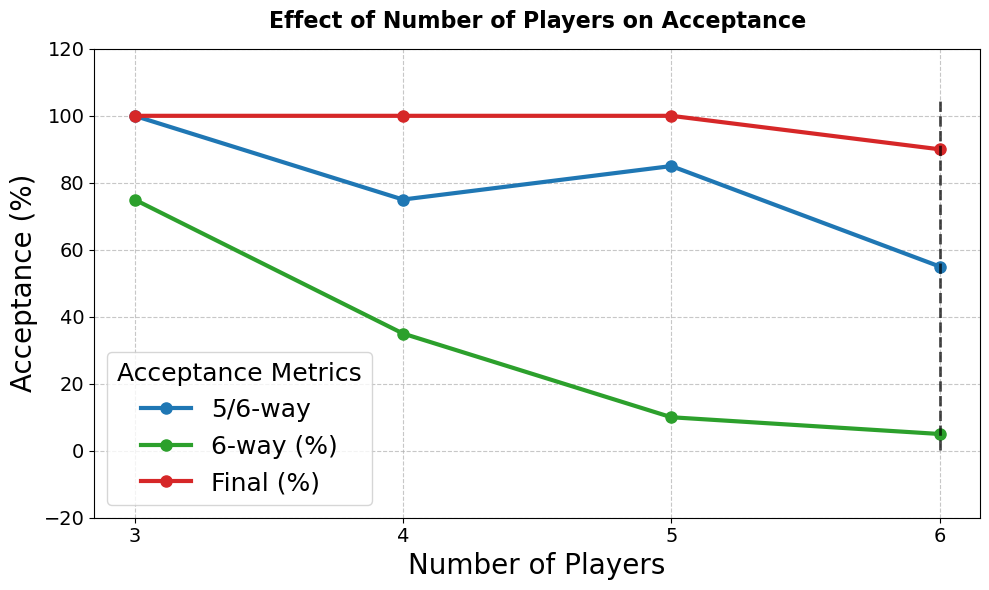

,5/6-way,6-way (%),Final (%),Players
3_players,100.0,75.0,100.0,3
4_players,75.0,35.0,100.0,4
5_players,85.0,10.0,100.0,5
base,55.0,5.0,90.0,6


In [6]:
# (2) Changing the number of players

import os
import eval_utils as evaluation
import json
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt


raw_path = '../our_games_descriptions/base/output/changing_num_players/gpt4o-mini'
variations = [
    "3_players",
    "4_players",
    "5_players",
    "base",
]

results = {}
ISSUES_NUM = 5
AGENTS_NUM = 6

for variation in variations:

    # Set the directory
    if variation == 'base':
        directory = '../our_games_descriptions/base/output/original_code/gpt4o-mini'
        agents_num = 6
    else:
        directory = os.path.join(raw_path, variation)
        agents_num = int(variation.split("_")[0])
    
    # Load the setup
    agents, role_to_agents, incentive_to_agents = evaluation.load_setup(directory, agents_num, num_issues=ISSUES_NUM)
    answers_files = [ os.path.join(directory,filename) for filename in os.listdir(directory) if filename.startswith("history")]

    num_rounds = 0
    for file_ in answers_files:
        answers = json.load(open(file_))
        _num_rounds = len(answers['rounds'])
        num_rounds = max(num_rounds, _num_rounds)

    # Track statistics
    feasible_in_last_step = 0
    accepted_by_all_in_last_step = 0
    contained_feasible_deal = 0
    successfull_games = 0
    total_rounds = 0

    # Loop through all answer files (each represents a game)
    for file_ in answers_files:
        answers = json.load(open(file_))
        
        if len(answers['rounds']) != num_rounds:
            print(f"WARNING: Game {file_} has a different number of rounds")
            continue
        total_rounds += len(answers['rounds'])
        successfull_games += 1

        # Extract deals for this game
        feasible_found = False

        # Extract the name of the first player (p1) to validate feasibility throughout the game
        p1_name = answers['rounds'][0]['agent']

        total_deals = 0
        
        for i, round_ in enumerate(answers['rounds']):
            name, answer = round_['agent'], round_['public_answer']
            deal_unformatted, issues_suggested = evaluation.extract_deal(answer, ISSUES_NUM)

            try:
                deal = evaluation.format_deal(deal_unformatted, ISSUES_NUM)
            except:
                print(f"Error in game {file_} round {i}")
                continue

            if issues_suggested >= ISSUES_NUM:
                total_deals += 1

            # Check if the deal was feasible at any point (Deal must have been proposed by p1)
            if evaluation.is_feasible(agents, deal) and name == p1_name:
                feasible_found = True
        

        # CHECK GAME COMPLETION METRICS

        last_deal = evaluation.format_deal(evaluation.extract_deal(answers['rounds'][-1]['public_answer'], ISSUES_NUM)[0], ISSUES_NUM)
        
        # 1. Check if the last deal is feasible
        if evaluation.is_feasible(agents, last_deal):
            feasible_in_last_step += 1

        # 2. Check if the last deal is acceptable by all agents
        all_accept = all(evaluation.calculator(agents[agent]["scores"], last_deal, ISSUES_NUM, verbose=False) >= agents[agent]["scores"]["min"] for agent in agents)
        if all_accept:
            accepted_by_all_in_last_step += 1

        # 3. Check if any deal during the game was in the feasibility set
        if feasible_found:
            contained_feasible_deal += 1

    # Compute percentages
    num_games = successfull_games
    perc_feasible_last = round((feasible_in_last_step / num_games) * 100, 2)
    perc_accepted_all_last = round((accepted_by_all_in_last_step / num_games) * 100, 2)
    perc_feasible_any = round((contained_feasible_deal / num_games) * 100, 2)

    results[variation] = {
        "5/6-way": perc_feasible_last,
        "6-way (%)": perc_accepted_all_last,
        "Final (%)": perc_feasible_any,
    }

df = pd.DataFrame(results).T

mapping = {
    "3_players": 3, "4_players": 4, "5_players": 5, "base": 6
}
df["Players"] = df.index.map(mapping)

# --- PLOTTING ---

import matplotlib.pyplot as plt

# Create a figure and axes object for finer control
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the DataFrame as a line plot on our chosen axes
# Increase linewidth, adjust markers, etc.
df.plot(
    x="Players",
    y=["5/6-way", "6-way (%)", "Final (%)"],
    kind="line",
    ax=ax,
    marker="o",
    markersize=8,
    linewidth=3,
    xlabel="Number of Players",
    ylabel="Acceptance (%)",
    fontsize=14,              # Adjust tick-label font size
    color=["#1f77b4", "#2ca02c", "#d62728"],  # Example custom colors
)

# Customize the main title
ax.set_title(
    "Effect of Number of Players on Acceptance", 
    fontsize=16, 
    fontweight="bold", 
    pad=15
)

ax.set_xlabel("Number of Players", fontsize=20)
ax.set_ylabel("Acceptance (%)", fontsize=20)

# (Optional) Add or refine a subtitle
# ax.set_title("Subtitle (optional)", fontsize=14, loc="center", pad=30)

# Draw a vertical line to highlight the 'base' scenario (6 players)
ymin, ymax = ax.get_ylim()  # get y-limits to draw the line properly
ax.vlines(x=6, ymin=ymin, ymax=ymax, 
          color="black", linestyle="--", linewidth=2, alpha=0.7)
# Add a small text label near the vertical line
# ax.text(5, ymax*0.85, "Base: 6 Players", fontsize=12, color="black")

# Configure x-ticks to show integer player counts
ax.set_xticks(df["Players"])  # ensures only the number of players are used as ticks
ax.set_yticks(ax.get_yticks())  # you can tweak y-ticks if desired

# Turn on a light grid
ax.grid(True, linestyle="--", alpha=0.7)

# Modify the legend
ax.legend(title="Acceptance Metrics", fontsize=18, title_fontsize=18, loc="best")

# Tight layout to reduce white space
plt.tight_layout()

# Display the plot
plt.show()

# Show the DataFrame below the plot, if desired
display(df)
